In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [1]:
# ============================================================
# KAGGLE — CLEAN HF INSTALL
# ============================================================

!pip uninstall -y \
    diffusers \
    huggingface-hub \
    transformers \
    accelerate \
    bitsandbytes \
    safetensors \
    tokenizers \
    hf-xet \
    -q

!pip install -q -U \
    "diffusers>=0.37.0" \
    "transformers>=4.57.0" \
    "accelerate>=1.10.0" \
    "safetensors>=0.5.3" \
    "sentencepiece" \
    "protobuf<6"


In [4]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
from pathlib import Path

import torch


# ============================================================
# 2. MEMORY SETTINGS
# ============================================================

os.environ["PYTORCH_ALLOC_CONF"] = (
    "expandable_segments:True"
)


# ============================================================
# 3. MODEL
# ============================================================

MODEL_ID = (
    "black-forest-labs/"
    "FLUX.2-klein-4b-nvfp4"
)


# ============================================================
# 4. PROMPT
# ============================================================

PROMPT = (
    'a cat holding a sign that says '
    '"hello world", '
    'cinematic lighting, '
    'highly detailed, '
    'photorealistic'
)


# ============================================================
# 5. IMAGE EDITING
#
# None = text-to-image
#
# Example:
#
# IMAGE_PATH = "/kaggle/input/my-image/cat.png"
#
# ============================================================

IMAGE_PATH = None


# ============================================================
# 6. GENERATION
# ============================================================

WIDTH = 512
HEIGHT = 512

STEPS = 20

GUIDANCE = 4.0

SEED = 0


# ============================================================
# 7. OUTPUT
# ============================================================

OUTPUT_DIR = Path(
    "/kaggle/working/outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    OUTPUT_DIR / "flux2_klein.png"
)
print("done")

done


In [5]:
# ============================================================
# GPU CHECK
# ============================================================

print("=" * 70)
print("FLUX.2-klein-4B — ENVIRONMENT")
print("=" * 70)

print(
    "PyTorch      :",
    torch.__version__
)

print(
    "CUDA         :",
    torch.version.cuda
)

print(
    "CUDA usable  :",
    torch.cuda.is_available()
)


if not torch.cuda.is_available():

    raise RuntimeError(
        "Không tìm thấy CUDA GPU. "
        "Kaggle → Settings → Accelerator → GPU."
    )


GPU_COUNT = torch.cuda.device_count()

print(
    "GPU count    :",
    GPU_COUNT
)


for i in range(GPU_COUNT):

    props = torch.cuda.get_device_properties(i)

    print(
        f"GPU {i:<2}       : "
        f"{torch.cuda.get_device_name(i)} "
        f"("
        f"{props.total_memory / 1024**3:.2f}"
        f" GB)"
    )


print("=" * 70)


FLUX.2-klein-4B — ENVIRONMENT
PyTorch      : 2.10.0+cu128
CUDA         : 12.8
CUDA usable  : True
GPU count    : 2
GPU 0        : Tesla T4 (14.56 GB)
GPU 1        : Tesla T4 (14.56 GB)


In [6]:
# ============================================================
# DEPENDENCY CHECK
# ============================================================

import diffusers
import transformers
import accelerate
import huggingface_hub


print()
print("=" * 70)
print("DEPENDENCIES")
print("=" * 70)

print(
    "Diffusers     :",
    diffusers.__version__
)

print(
    "Transformers  :",
    transformers.__version__
)

print(
    "Accelerate    :",
    accelerate.__version__
)

print(
    "HuggingFace   :",
    huggingface_hub.__version__
)

print("=" * 70)



DEPENDENCIES
Diffusers     : 0.40.0
Transformers  : 5.17.0
Accelerate    : 1.15.0
HuggingFace   : 1.32.0


FLUX.2-klein-4B — ENVIRONMENT
PyTorch      : 2.10.0+cu128
CUDA         : 12.8
CUDA usable  : True
GPU count    : 2
GPU 0        : Tesla T4 (14.56 GB)
GPU 1        : Tesla T4 (14.56 GB)

Cleaning GPU memory...

LOADING FLUX.2-klein-4B

Model: black-forest-labs/FLUX.2-klein-4B

Using bfloat16 + CPU offload.
This avoids loading the whole model into one T4.



model_index.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


Model loaded successfully.

ENABLING CPU OFFLOAD
CPU offload enabled.

Mode         : TEXT TO IMAGE

GENERATION CONFIG

Prompt       : a cat holding a sign that says "hello world", cinematic lighting, highly detailed, photorealistic
Resolution   : 512 x 512
Steps        : 4
Guidance     : 1.0
Seed         : 0
Output       : /kaggle/working/outputs/flux2_klein.png

GENERATING

Please wait...



  0%|          | 0/4 [00:00<?, ?it/s]


DONE

Model: black-forest-labs/FLUX.2-klein-4B
Output: /kaggle/working/outputs/flux2_klein.png
Resolution: (512, 512)
Steps: 4
Guidance: 1.0
Seed: 0

Image generated successfully.


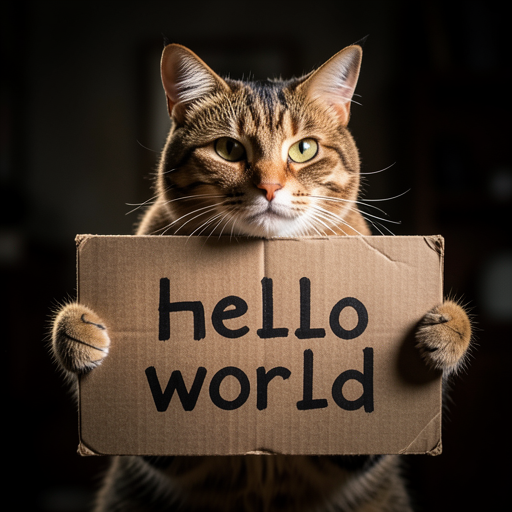

In [8]:
# ============================================================
# ASSIGNMENT 2.7
# FLUX.2-klein-4B — Diffusers Inference
# Kaggle — 2x Tesla T4
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
from pathlib import Path

import torch

from diffusers import Flux2KleinPipeline
from diffusers.utils import load_image


# ============================================================
# 2. CUDA MEMORY SETTINGS
# ============================================================

os.environ["PYTORCH_ALLOC_CONF"] = (
    "expandable_segments:True"
)


# ============================================================
# 3. CONFIG
# ============================================================

MODEL_ID = "black-forest-labs/FLUX.2-klein-4B"


# ------------------------------------------------------------
# Text-to-image prompt
# ------------------------------------------------------------

PROMPT = (
    'a cat holding a sign that says '
    '"hello world", '
    'cinematic lighting, '
    'highly detailed, '
    'photorealistic'
)


# ------------------------------------------------------------
# Image editing
#
# None = text-to-image
#
# Example:
#
# IMAGE_PATH = "/kaggle/input/my-image/cat.png"
# ------------------------------------------------------------

IMAGE_PATH = None


# ------------------------------------------------------------
# Generation
#
# FLUX.2-klein is distilled.
# 4 steps is the official example.
# ------------------------------------------------------------

WIDTH = 512
HEIGHT = 512

STEPS = 4

GUIDANCE = 1.0

SEED = 0


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/kaggle/working/outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    OUTPUT_DIR / "flux2_klein.png"
)


# ============================================================
# 4. ENVIRONMENT
# ============================================================

print("=" * 70)
print("FLUX.2-klein-4B — ENVIRONMENT")
print("=" * 70)

print(
    "PyTorch      :",
    torch.__version__
)

print(
    "CUDA         :",
    torch.version.cuda
)

print(
    "CUDA usable  :",
    torch.cuda.is_available()
)


if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU not found.\n"
        "Kaggle → Settings → Accelerator → GPU"
    )


GPU_COUNT = torch.cuda.device_count()

print(
    "GPU count    :",
    GPU_COUNT
)


for i in range(GPU_COUNT):

    props = torch.cuda.get_device_properties(i)

    print(
        f"GPU {i:<2}       : "
        f"{torch.cuda.get_device_name(i)} "
        f"({props.total_memory / 1024**3:.2f} GB)"
    )


print("=" * 70)


# ============================================================
# 5. CLEAN GPU MEMORY
# ============================================================

print()
print("Cleaning GPU memory...")

gc.collect()

for i in range(
    torch.cuda.device_count()
):

    with torch.cuda.device(i):

        torch.cuda.empty_cache()


# ============================================================
# 6. LOAD MODEL
# ============================================================

print()
print("=" * 70)
print("LOADING FLUX.2-klein-4B")
print("=" * 70)

print()
print(
    "Model:",
    MODEL_ID
)

print()
print(
    "Using bfloat16 + CPU offload."
)

print(
    "This avoids loading the whole model into one T4."
)

print()


try:

    pipe = Flux2KleinPipeline.from_pretrained(

        MODEL_ID,

        dtype=torch.bfloat16,

    )

except Exception as e:

    print()
    print("=" * 70)
    print("MODEL LOAD FAILED")
    print("=" * 70)

    print(
        "Error type:",
        type(e).__name__
    )

    print(
        "Error:",
        str(e)
    )

    raise


print()
print(
    "Model loaded successfully."
)


# ============================================================
# 7. MODEL CPU OFFLOAD
# ============================================================

print()
print("=" * 70)
print("ENABLING CPU OFFLOAD")
print("=" * 70)


# ------------------------------------------------------------
# IMPORTANT
#
# Do NOT use:
#
#     pipe.to("cuda")
#
# because the whole model would be placed on one T4.
#
# CPU offload moves components to GPU only when needed.
# ------------------------------------------------------------

pipe.enable_model_cpu_offload(
    gpu_id=0
)


print(
    "CPU offload enabled."
)


# ============================================================
# 8. VAE MEMORY OPTIMIZATION
# ============================================================

if hasattr(
    pipe,
    "enable_vae_slicing"
):

    pipe.enable_vae_slicing()

    print(
        "VAE slicing enabled."
    )


if hasattr(
    pipe,
    "enable_vae_tiling"
):

    pipe.enable_vae_tiling()

    print(
        "VAE tiling enabled."
    )


# ============================================================
# 9. GENERATOR
# ============================================================

generator = torch.Generator(
    device="cpu"
).manual_seed(
    SEED
)


# ============================================================
# 10. GENERATION ARGUMENTS
# ============================================================

call_kwargs = {

    "prompt": PROMPT,

    "height": HEIGHT,

    "width": WIDTH,

    "guidance_scale": GUIDANCE,

    "num_inference_steps": STEPS,

    "generator": generator,
}


# ============================================================
# 11. IMAGE EDITING
# ============================================================

if IMAGE_PATH is not None:

    image_path = Path(
        IMAGE_PATH
    )


    if not image_path.exists():

        raise FileNotFoundError(
            f"Image not found: {IMAGE_PATH}"
        )


    input_image = load_image(
        IMAGE_PATH
    )


    call_kwargs["image"] = input_image


    print()
    print(
        "Mode         : IMAGE EDITING"
    )

    print(
        "Input image  :",
        IMAGE_PATH
    )


else:

    print()
    print(
        "Mode         : TEXT TO IMAGE"
    )


# ============================================================
# 12. GENERATION CONFIG
# ============================================================

print()
print("=" * 70)
print("GENERATION CONFIG")
print("=" * 70)

print()
print(
    "Prompt       :",
    PROMPT
)

print(
    "Resolution   :",
    f"{WIDTH} x {HEIGHT}"
)

print(
    "Steps        :",
    STEPS
)

print(
    "Guidance     :",
    GUIDANCE
)

print(
    "Seed         :",
    SEED
)

print(
    "Output       :",
    OUTPUT_PATH
)

print("=" * 70)


# ============================================================
# 13. GENERATE
# ============================================================

print()
print("=" * 70)
print("GENERATING")
print("=" * 70)

print()
print(
    "Please wait..."
)

print()


try:

    with torch.inference_mode():

        result = pipe(
            **call_kwargs
        )


except torch.cuda.OutOfMemoryError:

    print()
    print("=" * 70)
    print("CUDA OUT OF MEMORY")
    print("=" * 70)

    print()
    print(
        "Try reducing:"
    )

    print(
        "WIDTH  = 384"
    )

    print(
        "HEIGHT = 384"
    )

    print()

    raise


# ============================================================
# 14. GET IMAGE
# ============================================================

image = result.images[0]


# ============================================================
# 15. SAVE
# ============================================================

image.save(
    OUTPUT_PATH
)


# ============================================================
# 16. CLEAN MEMORY
# ============================================================

del result

gc.collect()

for i in range(
    torch.cuda.device_count()
):

    with torch.cuda.device(i):

        torch.cuda.empty_cache()


# ============================================================
# 17. RESULT
# ============================================================

print()
print("=" * 70)
print("DONE")
print("=" * 70)

print()
print(
    "Model:",
    MODEL_ID
)

print(
    "Output:",
    OUTPUT_PATH
)

print(
    "Resolution:",
    image.size
)

print(
    "Steps:",
    STEPS
)

print(
    "Guidance:",
    GUIDANCE
)

print(
    "Seed:",
    SEED
)

print()
print(
    "Image generated successfully."
)

print("=" * 70)


# ============================================================
# 18. DISPLAY
# ============================================================

display(image)

In [ ]:
# ============================================================
# Assignment 2.7 — FLUX.2-dev
# Kaggle Notebook — 2x Tesla T4
#
# FLUX.2-dev 4-bit
# Text encoder GROUP OFFLOAD
# ============================================================


# ============================================================
# 0. ENVIRONMENT
# ============================================================

import os

# Must be set before importing torch
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import gc
from pathlib import Path

import torch


# ============================================================
# 1. CONFIG
# ============================================================

MODEL_ID = "diffusers/FLUX.2-dev-bnb-4bit"

PROMPT = (
    'a cat holding a sign that says "hello world", '
    "cinematic lighting, highly detailed, photorealistic"
)

IMAGE_PATH = None


# ------------------------------------------------------------
# Generation
# ------------------------------------------------------------

STEPS = 20
GUIDANCE = 4.0
SEED = 0


# ------------------------------------------------------------
# Start very small.
#
# This does NOT solve text encoder OOM.
# It simply reduces image-generation memory.
# ------------------------------------------------------------

WIDTH = 512
HEIGHT = 512


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = Path(
    "/kaggle/working/outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    OUTPUT_DIR / "flux2.png"
)


# ============================================================
# 2. GPU CHECK
# ============================================================

print("=" * 70)
print("FLUX.2-dev — GPU")
print("=" * 70)

print("PyTorch     :", torch.__version__)
print("CUDA        :", torch.version.cuda)
print("CUDA usable :", torch.cuda.is_available())


if not torch.cuda.is_available():

    raise RuntimeError(
        "Không tìm thấy CUDA GPU."
    )


GPU_COUNT = torch.cuda.device_count()

print("GPU count   :", GPU_COUNT)


for i in range(GPU_COUNT):

    props = torch.cuda.get_device_properties(i)

    print(
        f"GPU {i:<2}      : "
        f"{torch.cuda.get_device_name(i)} "
        f"({props.total_memory / 1024**3:.2f} GB)"
    )


print("=" * 70)


# ============================================================
# 3. DEPENDENCIES
# ============================================================

import diffusers
import transformers
import accelerate
import bitsandbytes
import huggingface_hub


print()
print("=" * 70)
print("DEPENDENCIES")
print("=" * 70)

print(
    "Diffusers     :",
    diffusers.__version__
)

print(
    "Transformers  :",
    transformers.__version__
)

print(
    "Accelerate    :",
    accelerate.__version__
)

print(
    "BitsAndBytes  :",
    bitsandbytes.__version__
)

print(
    "HF Hub        :",
    huggingface_hub.__version__
)

print("=" * 70)


# ============================================================
# 4. IMPORTS
# ============================================================

from diffusers import DiffusionPipeline

from diffusers.hooks import apply_group_offloading


# ============================================================
# 5. CLEAN CUDA
# ============================================================

print()
print("Cleaning CUDA cache...")

gc.collect()

for i in range(
    torch.cuda.device_count()
):

    with torch.cuda.device(i):

        torch.cuda.empty_cache()


# ============================================================
# 6. LOAD MODEL
# ============================================================

print()
print("=" * 70)
print("LOADING FLUX.2-dev 4-BIT")
print("=" * 70)

print()
print("Model:")
print(MODEL_ID)

print()
print(
    "Loading pipeline on CPU first..."
)


try:

    pipe = DiffusionPipeline.from_pretrained(

        MODEL_ID,

        torch_dtype=torch.bfloat16,

        # ----------------------------------------------------
        # VERY IMPORTANT
        #
        # Do NOT put the model on GPU during loading.
        # ----------------------------------------------------

        device_map="cpu",

        low_cpu_mem_usage=True,

        offload_folder=(
            "/kaggle/working/"
            "flux2_offload"
        ),

        offload_state_dict=True,
    )


except Exception as e:

    print()
    print("=" * 70)
    print("MODEL LOAD FAILED")
    print("=" * 70)

    print(
        type(e).__name__
    )

    print(
        str(e)
    )

    raise


print()
print("Pipeline loaded on CPU.")


# ============================================================
# 7. COMPONENTS
# ============================================================

print()
print("=" * 70)
print("PIPELINE COMPONENTS")
print("=" * 70)

for name in pipe.components:

    print(
        "-",
        name
    )

print("=" * 70)


# ============================================================
# 8. IMPORTANT:
#    TEXT ENCODER GROUP OFFLOAD
# ============================================================

print()
print("=" * 70)
print("TEXT ENCODER OFFLOAD")
print("=" * 70)

print()
print(
    "Applying block-level group offload "
    "to Mistral-3..."
)


# ------------------------------------------------------------
# Mistral-3 has 40 language layers.
#
# Only a small group is placed on GPU at a time.
#
# This prevents the entire ~15 GB text encoder from
# occupying the 14.56 GB T4.
# ------------------------------------------------------------

apply_group_offloading(

    pipe.text_encoder,

    onload_device=torch.device(
        "cuda:0"
    ),

    offload_device=torch.device(
        "cpu"
    ),

    offload_type="block_level",

    num_blocks_per_group=1,

    use_stream=False,

    low_cpu_mem_usage=True,
)


print(
    "Text encoder group offload enabled."
)


# ============================================================
# 9. TRANSFORMER GROUP OFFLOAD
# ============================================================

print()
print("=" * 70)
print("TRANSFORMER OFFLOAD")
print("=" * 70)


# ------------------------------------------------------------
# The transformer is ~18 GB in the 4-bit checkpoint.
#
# It also cannot reside entirely on one T4.
#
# Group offload allows individual transformer blocks to
# move between CPU and GPU.
# ------------------------------------------------------------

pipe.transformer.enable_group_offload(

    onload_device=torch.device(
        "cuda:1"
    ),

    offload_device=torch.device(
        "cpu"
    ),

    offload_type="block_level",

    num_blocks_per_group=1,

    use_stream=False,

    low_cpu_mem_usage=True,
)


print(
    "Transformer group offload enabled."
)


# ============================================================
# 10. VAE
# ============================================================

print()
print("=" * 70)
print("VAE")
print("=" * 70)


# ------------------------------------------------------------
# VAE is much smaller.
#
# Put it on GPU 0 when needed.
# ------------------------------------------------------------

if hasattr(
    pipe.vae,
    "enable_slicing"
):

    pipe.vae.enable_slicing()

    print(
        "VAE slicing enabled."
    )


if hasattr(
    pipe.vae,
    "enable_tiling"
):

    pipe.vae.enable_tiling()

    print(
        "VAE tiling enabled."
    )


# ============================================================
# 11. GENERATOR
# ============================================================

generator = torch.Generator(
    device="cpu"
).manual_seed(
    SEED
)


# ============================================================
# 12. GENERATION ARGUMENTS
# ============================================================

call_kwargs = {

    "prompt": PROMPT,

    "guidance_scale": GUIDANCE,

    "num_inference_steps": STEPS,

    "generator": generator,

    "width": WIDTH,

    "height": HEIGHT,
}


# ============================================================
# 13. IMAGE EDITING
# ============================================================

if IMAGE_PATH is not None:

    if not Path(
        IMAGE_PATH
    ).exists():

        raise FileNotFoundError(
            IMAGE_PATH
        )


    from diffusers.utils import load_image


    call_kwargs["image"] = load_image(
        IMAGE_PATH
    )


    print()
    print(
        "Mode: IMAGE EDITING"
    )

else:

    print()
    print(
        "Mode: TEXT TO IMAGE"
    )


# ============================================================
# 14. GENERATE
# ============================================================

print()
print("=" * 70)
print("GENERATING")
print("=" * 70)

print()
print("Prompt :", PROMPT)
print("Steps  :", STEPS)
print("CFG    :", GUIDANCE)
print("Seed   :", SEED)
print(
    "Size   :",
    WIDTH,
    "x",
    HEIGHT
)

print()
print(
    "Starting inference..."
)

print()


try:

    with torch.inference_mode():

        result = pipe(
            **call_kwargs
        )


except torch.cuda.OutOfMemoryError:

    print()
    print("=" * 70)
    print("CUDA OOM DURING GENERATION")
    print("=" * 70)

    print()
    print(
        "Even with group offloading, "
        "the current configuration "
        "exceeded VRAM."
    )

    print()
    print(
        "Next fallback:"
    )

    print(
        "WIDTH  = 384"
    )

    print(
        "HEIGHT = 384"
    )

    print(
        "STEPS  = 12"
    )

    raise


# ============================================================
# 15. SAVE
# ============================================================

image = result.images[0]


image.save(
    OUTPUT_PATH
)


# ============================================================
# 16. CLEAN
# ============================================================

gc.collect()


for i in range(
    torch.cuda.device_count()
):

    with torch.cuda.device(i):

        torch.cuda.empty_cache()


# ============================================================
# 17. DONE
# ============================================================

print()
print("=" * 70)
print("DONE")
print("=" * 70)

print()
print(
    "Output:",
    OUTPUT_PATH
)

print(
    "Size:",
    image.size
)

print(
    "Seed:",
    SEED
)

print(
    "Steps:",
    STEPS
)

print(
    "Guidance:",
    GUIDANCE
)

print("=" * 70)


# ============================================================
# 18. DISPLAY
# ============================================================

display(image)
